In [1]:
!pip install librosa 

In [2]:
import librosa
print(librosa.__version__)

0.11.0


In [3]:
import numpy as np
import os 

In [4]:

import librosa


X = []
y = []

dataset_path = "../Dataset"  
for person in os.listdir(dataset_path):
    person_folder = os.path.join(dataset_path, person)

    for file_name in os.listdir(person_folder):
        file_path = os.path.join(person_folder, file_name)

        audio, sr = librosa.load(file_path, sr=None)

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)

        X.append(mfcc_mean)
        y.append(person)

X = np.array(X)
y = np.array(y)

In [5]:


print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (55, 13)
Shape de y : (55,)


In [6]:
np.save("X.npy", X)
np.save("y.npy", y)

In [7]:
print(os.getcwd())

c:\Users\emanc\reconnaissance-vocal\code


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import BernoulliRBM
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Pour sauvegarder les modèles
import joblib

In [9]:
# Configuration des visualisations
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

In [12]:
# Charger les MFCC que vous avez déjà calculés
X = np.load("X.npy")  # Shape: (55, 13)
y = np.load("y.npy")  # Shape: (55,)

In [11]:
print("="*50)
print("CHARGEMENT DES DONNÉES")
print("="*50)
print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")
print(f"Nombre d'échantillons : {X.shape[0]}")
print(f"Nombre de features MFCC : {X.shape[1]}")
print(f"Nombre de locuteurs uniques : {len(np.unique(y))}")
print(f"Locuteurs : {np.unique(y)}")

CHARGEMENT DES DONNÉES
Shape de X : (55, 13)
Shape de y : (55,)
Nombre d'échantillons : 55
Nombre de features MFCC : 13
Nombre de locuteurs uniques : 11
Locuteurs : ['Farissi_Fatimaezzahra' 'Fatima ezzahra talhi' 'Halima_Moutcho'
 'Hiba_ELIdrisy' 'Imane_Chalati' 'Khadija_El_boudhiri'
 'Oueld Aadou Kawtar' 'Oumaima_Khalil' 'Salma_Nghira' 'Sara Domti'
 'Zaitoun Dounia']


In [13]:
# 3. ÉTAPE 1: NORMALISATION DES DONNÉES


# StandardScaler: moyenne=0, écart-type=1
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("Normalisation terminée")
print(f"Avant normalisation - Moyenne: {X.mean():.3f}, Std: {X.std():.3f}")
print(f"Après normalisation - Moyenne: {X_normalized.mean():.3f}, Std: {X_normalized.std():.3f}")


Normalisation terminée
Avant normalisation - Moyenne: -25.178, Std: 123.571
Après normalisation - Moyenne: -0.000, Std: 1.000


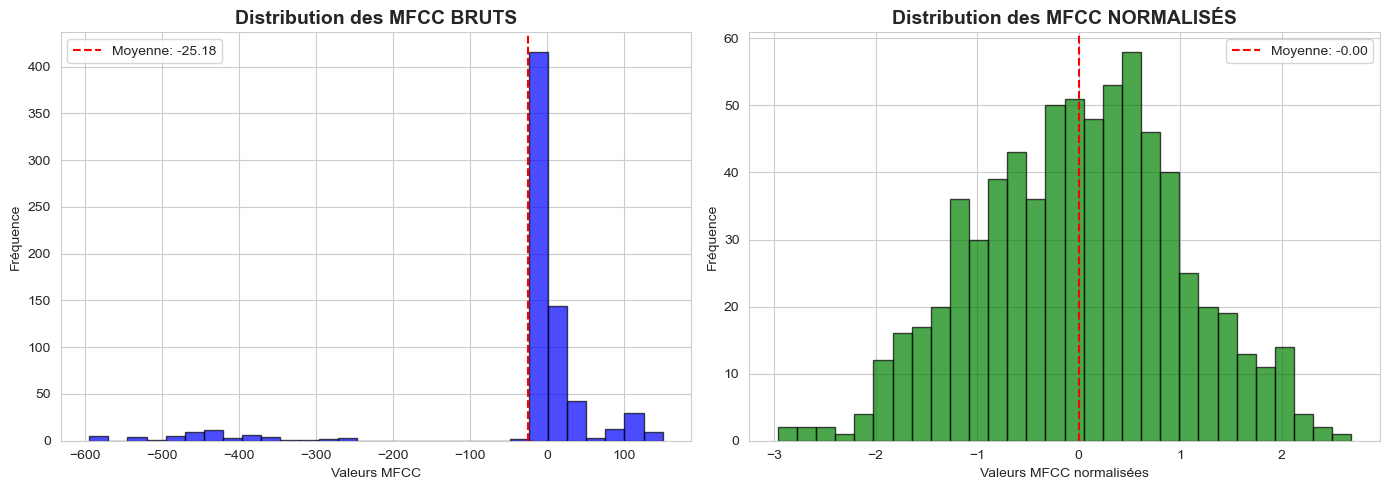

In [14]:
# Visualisation de l'effet de la normalisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant normalisation
axes[0].hist(X.flatten(), bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Distribution des MFCC BRUTS', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valeurs MFCC')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(x=X.mean(), color='red', linestyle='--', label=f'Moyenne: {X.mean():.2f}')
axes[0].legend()

# Après normalisation
axes[1].hist(X_normalized.flatten(), bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribution des MFCC NORMALISÉS', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valeurs MFCC normalisées')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(x=X_normalized.mean(), color='red', linestyle='--', label=f'Moyenne: {X_normalized.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()



 4. CRÉATION DE L'UBM (UNIVERSAL BACKGROUND MODEL)

"""
L'UBM représente le modèle de voix "générique"

Il est entraîné sur plusieurs locuteurs pour apprendre les caractéristiques communes
"""

In [16]:
# Obtenir les locuteurs uniques
unique_speakers = np.unique(y)
n_speakers = len(unique_speakers)


In [17]:
# Séparation: 70% pour UBM, 30% pour test
n_ubm_speakers = int(0.7 * n_speakers)
ubm_speakers = unique_speakers[:n_ubm_speakers]
test_speakers = unique_speakers[n_ubm_speakers:]

print(f"Locuteurs UBM (entraînement) : {len(ubm_speakers)}")
for spk in ubm_speakers:
    count = np.sum(y == spk)
    print(f"   - {spk}: {count} échantillons")

print(f"\nLocuteurs de test : {len(test_speakers)}")
for spk in test_speakers:
    count = np.sum(y == spk)
    print(f"   - {spk}: {count} échantillons")

Locuteurs UBM (entraînement) : 7
   - Farissi_Fatimaezzahra: 5 échantillons
   - Fatima ezzahra talhi: 5 échantillons
   - Halima_Moutcho: 5 échantillons
   - Hiba_ELIdrisy: 5 échantillons
   - Imane_Chalati: 5 échantillons
   - Khadija_El_boudhiri: 5 échantillons
   - Oueld Aadou Kawtar: 5 échantillons

Locuteurs de test : 4
   - Oumaima_Khalil: 5 échantillons
   - Salma_Nghira: 5 échantillons
   - Sara Domti: 5 échantillons
   - Zaitoun Dounia: 5 échantillons


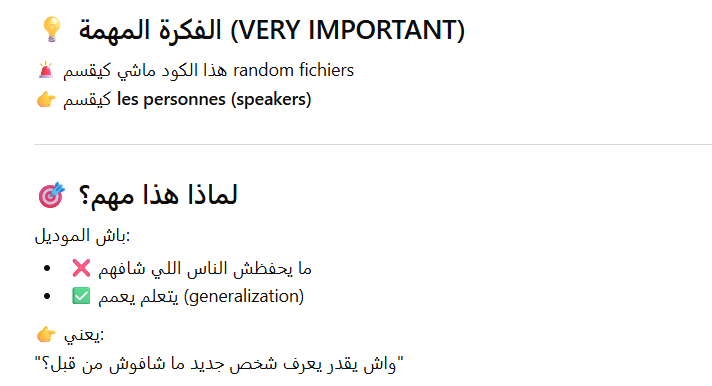

In [18]:
# Créer les ensembles
X_ubm = X_normalized[np.isin(y, ubm_speakers)]
y_ubm = y[np.isin(y, ubm_speakers)]

X_test = {}
y_test = {}
for speaker in test_speakers:
    mask = y == speaker
    X_test[speaker] = X_normalized[mask]
    y_test[speaker] = y[mask]

print(f"\nUBM créé avec {X_ubm.shape[0]} échantillons")



UBM créé avec 35 échantillons


In [20]:
# 5. ÉTAPE 3: ENTRAÎNEMENT DE LA RBM SUR L'UBM
# Pour BernoulliRBM, les données doivent être entre 0 et 1
# Nous utilisons MinMaxScaler pour cela
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_ubm_scaled = minmax_scaler.fit_transform(X_ubm)

# Paramètres de la RBM
N_VISIBLE = X.shape[1]  # 13 coefficients MFCC
N_HIDDEN = 32  # Nombre de neurones cachés (vous pouvez tester 16, 32, 64)
LEARNING_RATE = 0.01
N_ITER = 200
BATCH_SIZE = 10

# Créer et entraîner la RBM
rbm = BernoulliRBM(
    n_components=N_HIDDEN,
    learning_rate=LEARNING_RATE,
    n_iter=N_ITER,
    batch_size=BATCH_SIZE,
    random_state=42,
    verbose=True
)

print("\n Entraînement en cours...")
rbm.fit(X_ubm_scaled)
print(" RBM entraînée avec succès !")



 Entraînement en cours...
[BernoulliRBM] Iteration 1, pseudo-likelihood = -9.00, time = 0.01s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -8.97, time = 0.01s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -8.97, time = 0.00s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -8.97, time = 0.00s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -8.96, time = 0.00s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -8.99, time = 0.00s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -8.98, time = 0.00s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -9.00, time = 0.00s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -9.00, time = 0.00s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -8.98, time = 0.00s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -8.97, time = 0.00s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -8.96, time = 0.00s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -8.96, time = 0.00s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -8.97, time = 0.00s
[BernoulliRBM] I

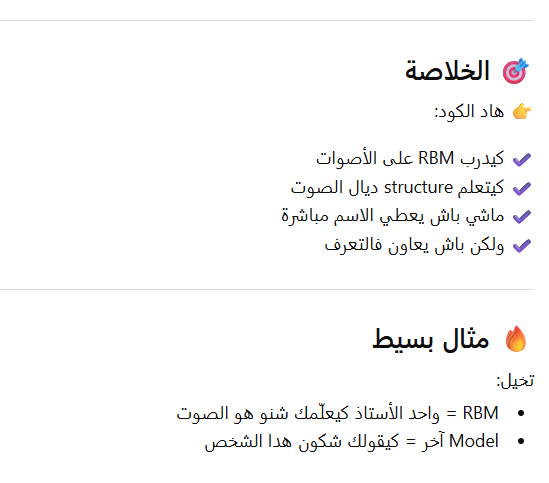

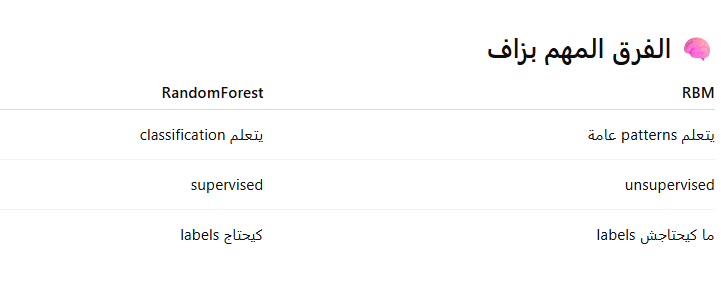

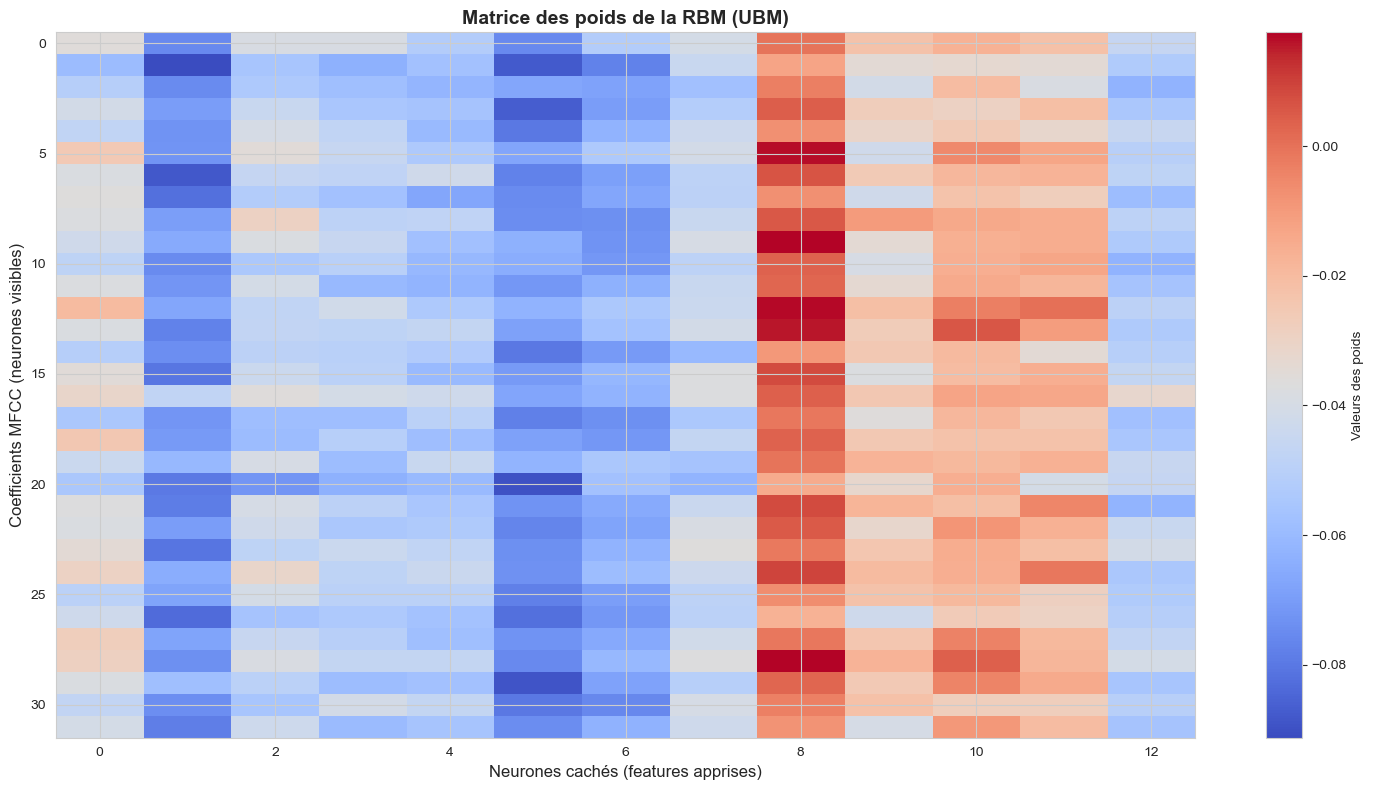

In [21]:
# Visualiser les poids de la RBM
plt.figure(figsize=(15, 8))
plt.imshow(rbm.components_, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Valeurs des poids')
plt.title('Matrice des poids de la RBM (UBM)', fontsize=14, fontweight='bold')
plt.xlabel('Neurones cachés (features apprises)', fontsize=12)
plt.ylabel('Coefficients MFCC (neurones visibles)', fontsize=12)
plt.tight_layout()
plt.show()

Extrait une matrice de poids unique pour un locuteur
    
    La matrice est créée en combinant:
    - Les poids appris par la RBM
    - Les activations spécifiques du locuteur
    
    Retourne une matrice de taille (N_visible, N_hidden)

In [24]:
# 6. ÉTAPE 4: EXTRACTION DES MATRICES DE POIDS PAR LOCUTEUR

def extract_speaker_weight_matrix(rbm, speaker_data, minmax_scaler):
    # Normaliser les données du locuteur
    speaker_data_scaled = minmax_scaler.transform(speaker_data)
    
    # Calculer les activations de la couche cachée pour ce locuteur
    hidden_activations = rbm._mean_hiddens(speaker_data_scaled)
    
    # Moyenne des activations cachées
    mean_hidden = np.mean(hidden_activations, axis=0)
    
    # Moyenne des données visibles (MFCC normalisés)
    mean_visible = np.mean(speaker_data_scaled, axis=0)
    
    # Créer la matrice de poids spécifique (produit extérieur)
    # Cette matrice capture la relation entre les MFCC et les features apprises
    weight_matrix = np.outer(mean_visible, mean_hidden)
    
    return weight_matrix


In [26]:
# Extraire les matrices pour tous les locuteurs de test
speaker_matrices = {}
speaker_means = {}

for speaker in test_speakers:
    if len(X_test[speaker]) > 0:
        weight_matrix = extract_speaker_weight_matrix(rbm, X_test[speaker], minmax_scaler)
        speaker_matrices[speaker] = weight_matrix
        speaker_means[speaker] = np.mean(X_test[speaker], axis=0)
        
        print(f" {speaker}:")
        print(f"   - Matrice de taille: {weight_matrix.shape}")
        print(f"   - Norme de la matrice: {np.linalg.norm(weight_matrix):.4f}")

print(f"\n {len(speaker_matrices)} matrices de poids extraites !")


 Oumaima_Khalil:
   - Matrice de taille: (13, 32)
   - Norme de la matrice: 2.7170
 Salma_Nghira:
   - Matrice de taille: (13, 32)
   - Norme de la matrice: 2.1150
 Sara Domti:
   - Matrice de taille: (13, 32)
   - Norme de la matrice: 3.3300
 Zaitoun Dounia:
   - Matrice de taille: (13, 32)
   - Norme de la matrice: 3.3163

 4 matrices de poids extraites !


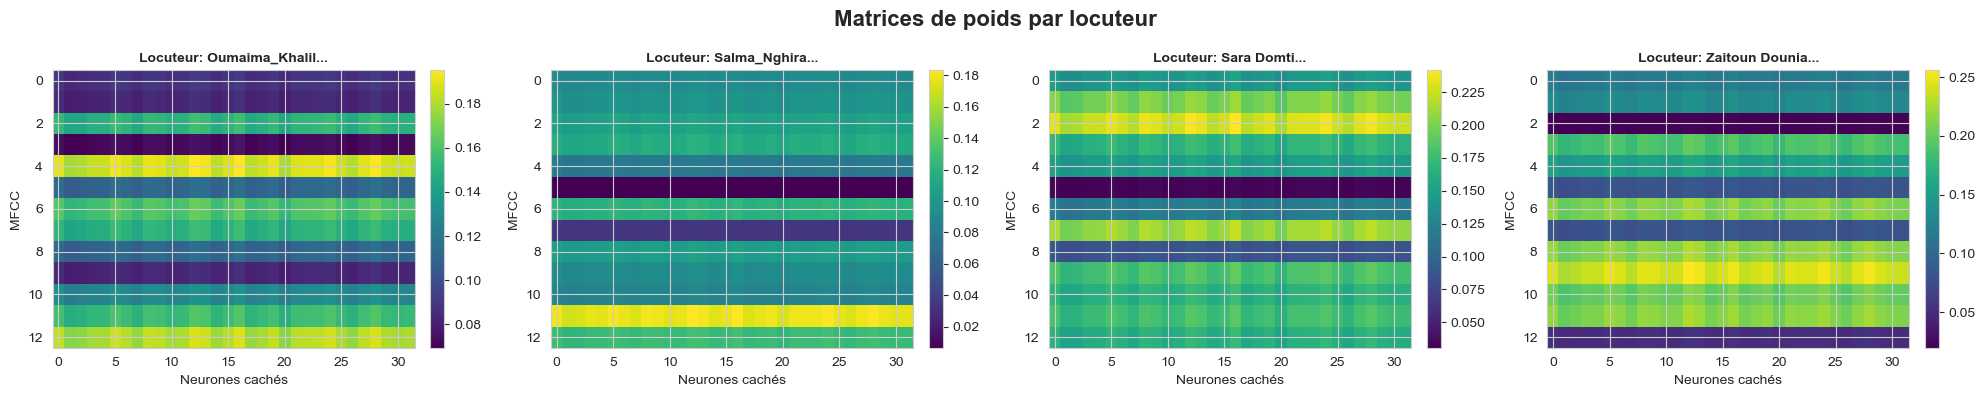

In [27]:
# 7. VISUALISATION DES MATRICES DE POIDS
# Visualiser chaque matrice de poids
n_speakers_test = len(speaker_matrices)
fig, axes = plt.subplots(1, n_speakers_test, figsize=(5*n_speakers_test, 4))

if n_speakers_test == 1:
    axes = [axes]

for idx, (speaker, matrix) in enumerate(speaker_matrices.items()):
    im = axes[idx].imshow(matrix, cmap='viridis', aspect='auto')
    axes[idx].set_title(f'Locuteur: {speaker[:15]}...', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Neurones cachés')
    axes[idx].set_ylabel('MFCC')
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Matrices de poids par locuteur', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


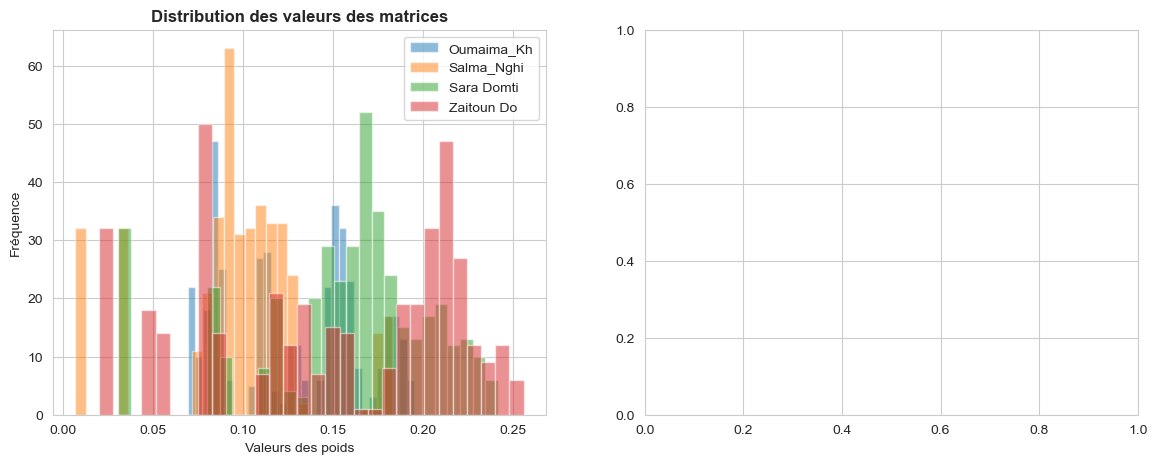

In [34]:
# Comparaison des distributions des matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des valeurs dans chaque matrice
for speaker, matrix in speaker_matrices.items():
    axes[0].hist(matrix.flatten(), alpha=0.5, bins=30, label=speaker[:10])
axes[0].set_title('Distribution des valeurs des matrices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valeurs des poids')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

In [35]:
# Heatmap de similarité entre locuteurs
from scipy.spatial.distance import pdist, squareform

# Calculer les distances entre matrices
speaker_list = list(speaker_matrices.keys())
n_speakers = len(speaker_list)
distance_matrix = np.zeros((n_speakers, n_speakers))

for i, spk1 in enumerate(speaker_list):
    for j, spk2 in enumerate(speaker_list):
        # Distance de Frobenius entre les matrices
        distance_matrix[i, j] = np.linalg.norm(speaker_matrices[spk1] - speaker_matrices[spk2], 'fro')

In [36]:
# Afficher la matrice de distance
im = axes[1].imshow(distance_matrix, cmap='hot', interpolation='nearest')
axes[1].set_title('Matrice de distance entre locuteurs', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(n_speakers))
axes[1].set_yticks(range(n_speakers))
axes[1].set_xticklabels(speaker_list, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(speaker_list, fontsize=8)
plt.colorbar(im, ax=axes[1], label='Distance de Frobenius')

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

In [37]:
# 8. SAUVEGARDE DES MODÈLES ET MATRICES

# Créer un dossier pour les modèles
os.makedirs("models", exist_ok=True)
os.makedirs("matrices", exist_ok=True)


In [38]:
# Sauvegarder les modèles
joblib.dump(rbm, "models/rbm_ubm.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(minmax_scaler, "models/minmax_scaler.pkl")


['models/minmax_scaler.pkl']

In [39]:
# Sauvegarder les matrices de poids
for speaker, matrix in speaker_matrices.items():
    np.save(f"matrices/weight_matrix_{speaker}.npy", matrix)

# Sauvegarder les informations
info = {
    'n_mfcc': N_VISIBLE,
    'n_hidden': N_HIDDEN,
    'ubm_speakers': ubm_speakers.tolist(),
    'test_speakers': test_speakers.tolist(),
    'speaker_matrices_shape': {spk: matrix.shape for spk, matrix in speaker_matrices.items()}
}


In [40]:
import json
with open("models/info.json", "w") as f:
    json.dump(info, f, indent=2)

print("Modèles sauvegardés dans 'models/'")
print("Matrices sauvegardées dans 'matrices/'")
print("Informations sauvegardées")


Modèles sauvegardés dans 'models/'
Matrices sauvegardées dans 'matrices/'
Informations sauvegardées


In [41]:
# 9. FONCTION DE PRÉDICTION POUR UN NOUVEL AUDIO
def predict_speaker_from_audio(audio_path, rbm, scaler, minmax_scaler, speaker_matrices):
    # Charger l'audio
    audio, sr = librosa.load(audio_path, sr=None)
    
    # Extraire les MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1).reshape(1, -1)
    
    # Normalisation (comme pour l'entraînement)
    mfcc_normalized = scaler.transform(mfcc_mean)
    mfcc_scaled = minmax_scaler.transform(mfcc_normalized)
    
    # Calculer la matrice de poids pour ce nouvel audio
    hidden_activations = rbm._mean_hiddens(mfcc_scaled)
    weight_matrix_new = np.outer(mfcc_scaled[0], hidden_activations[0])
    
    # Comparer avec tous les locuteurs
    distances = {}
    for speaker, ref_matrix in speaker_matrices.items():
        # Vérifier les dimensions
        if weight_matrix_new.shape != ref_matrix.shape:
            # Ajuster les dimensions si nécessaire
            if weight_matrix_new.shape[1] < ref_matrix.shape[1]:
                padding = ref_matrix.shape[1] - weight_matrix_new.shape[1]
                weight_matrix_new = np.pad(weight_matrix_new, ((0,0), (0,padding)), mode='constant')
            elif weight_matrix_new.shape[1] > ref_matrix.shape[1]:
                weight_matrix_new = weight_matrix_new[:, :ref_matrix.shape[1]]
        
        # Calculer la distance de Frobenius
        distance = np.linalg.norm(weight_matrix_new - ref_matrix, 'fro')
        distances[speaker] = distance
    
    # Trouver le locuteur avec la plus petite distance
    best_speaker = min(distances, key=distances.get)
    best_distance = distances[best_speaker]
    
    # Afficher les résultats
    print(f"\nRésultats de la prédiction:")
    print(f"   - Locuteur prédit: {best_speaker}")
    print(f"   - Distance: {best_distance:.4f}")
    print(f"\nScores de similarité (distance plus petite = plus similaire):")
    for speaker, dist in sorted(distances.items(), key=lambda x: x[1]):
        similarity = 1 / (1 + dist)  # Convertir distance en similarité
        print(f"   - {speaker}: distance={dist:.4f}, similarité={similarity:.4f}")
    
    return best_speaker, distances

In [43]:
# 10. TEST AVEC UN FICHIER AUDIO EXISTANT
# Chercher un fichier audio de test dans le dataset
dataset_path = "../Dataset"  # Ajustez le chemin selon votre structure

if os.path.exists(dataset_path):
    # Prendre un fichier audio d'un locuteur de test
    for speaker in test_speakers:
        speaker_folder = os.path.join(dataset_path, speaker)
        if os.path.exists(speaker_folder):
            audio_files = [f for f in os.listdir(speaker_folder) if f.endswith('.wav')]
            if audio_files:
                test_audio = os.path.join(speaker_folder, audio_files[0])
                print(f"\n🔍 Test avec: {test_audio}")
                print(f"   Locuteur réel: {speaker}")
                
                # Prédire
                predicted, distances = predict_speaker_from_audio(
                    test_audio, rbm, scaler, minmax_scaler, speaker_matrices
                )
                
                # Vérifier si la prédiction est correcte
                if predicted == speaker:
                    print(f"\nPRÉDICTION CORRECTE !")
                else:
                    print(f"\nPRÉDICTION INCORRECTE (prédit: {predicted})")
                break
            break
else:
    print("Dossier Dataset non trouvé, impossible de tester")



🔍 Test avec: ../Dataset\Oumaima_Khalil\WhatsApp Ptt 2026-03-30 at 23.55.04.wav
   Locuteur réel: Oumaima_Khalil

Résultats de la prédiction:
   - Locuteur prédit: Oumaima_Khalil
   - Distance: 0.6279

Scores de similarité (distance plus petite = plus similaire):
   - Oumaima_Khalil: distance=0.6279, similarité=0.6143
   - Salma_Nghira: distance=1.3759, similarité=0.4209
   - Sara Domti: distance=1.3819, similarité=0.4198
   - Zaitoun Dounia: distance=1.6124, similarité=0.3828

PRÉDICTION CORRECTE !



📈 ÉTAPE 9: ANALYSE STATISTIQUE

📊 Statistiques des matrices de poids:

   Oumaima_Khalil:
   - Moyenne: 0.1278
   - Écart-type: 0.0376
   - Valeur min: 0.0693
   - Valeur max: 0.1954
   - Norme: 2.7170

   Salma_Nghira:
   - Moyenne: 0.0955
   - Écart-type: 0.0403
   - Valeur min: 0.0066
   - Valeur max: 0.1835
   - Norme: 2.1150

   Sara Domti:
   - Moyenne: 0.1552
   - Écart-type: 0.0508
   - Valeur min: 0.0307
   - Valeur max: 0.2419
   - Norme: 3.3300

   Zaitoun Dounia:
   - Moyenne: 0.1471
   - Écart-type: 0.0693
   - Valeur min: 0.0198
   - Valeur max: 0.2561
   - Norme: 3.3163


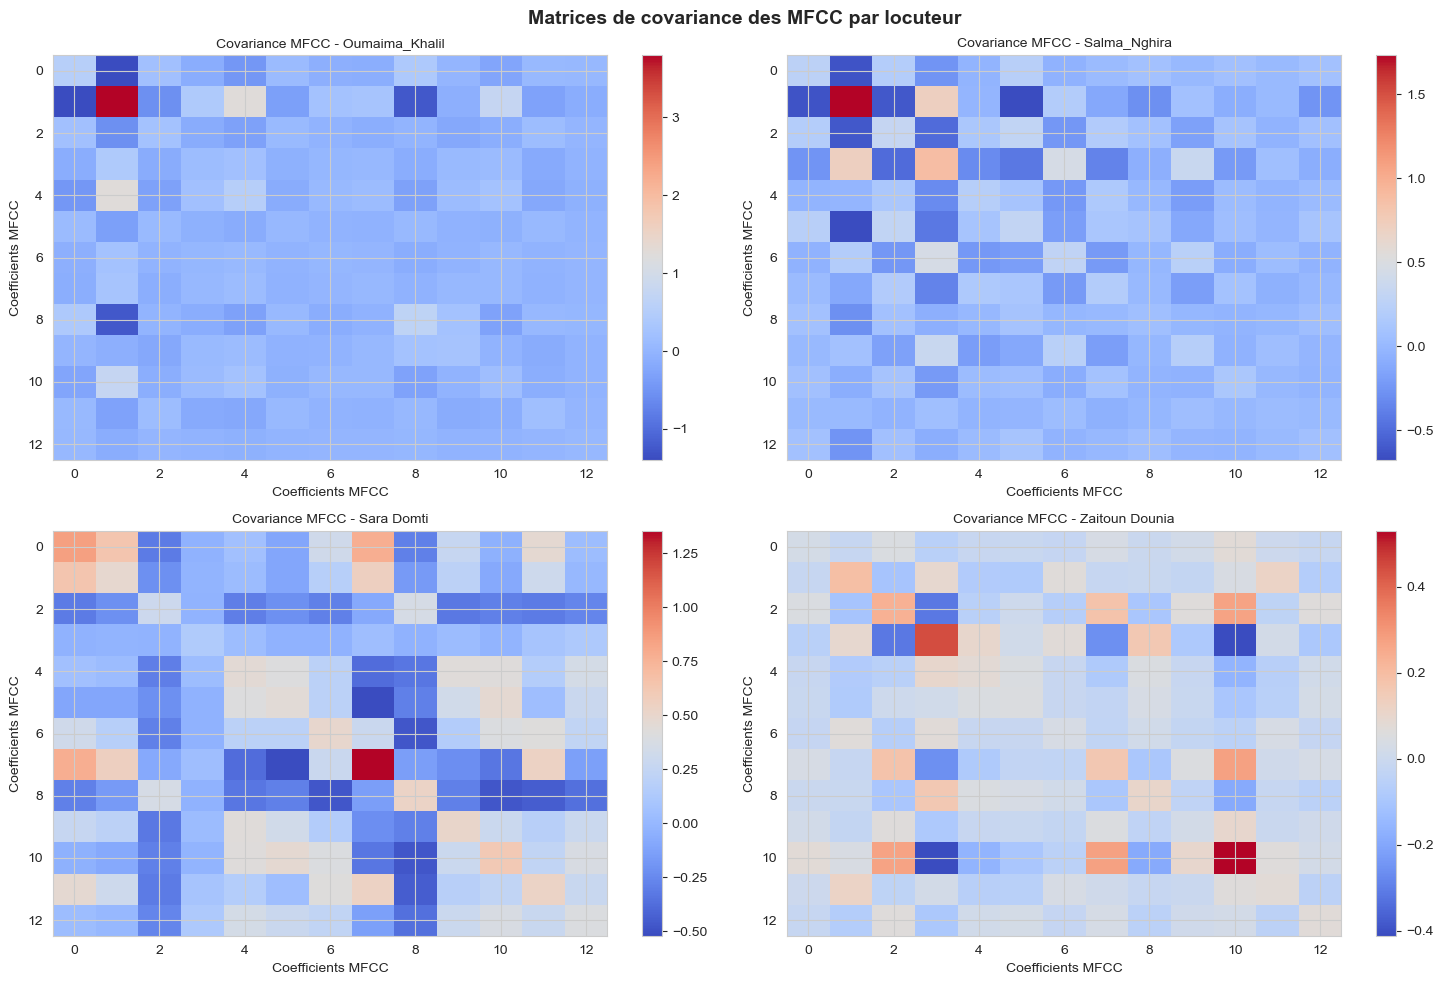


🎉 FIN DU PROCESSUS !

Résumé des fichiers créés:
   - models/rbm_ubm.pkl : Modèle RBM entraîné
   - models/scaler.pkl : StandardScaler pour normalisation
   - models/minmax_scaler.pkl : MinMaxScaler pour RBM
   - matrices/weight_matrix_*.npy : Matrices de poids par locuteur
   - models/info.json : Informations sur l'entraînement


In [44]:
# ============================================
# 11. ANALYSE STATISTIQUE
# ============================================
print("\n" + "="*50)
print("📈 ÉTAPE 9: ANALYSE STATISTIQUE")
print("="*50)

# Statistiques sur les matrices
print("\n📊 Statistiques des matrices de poids:")
for speaker, matrix in speaker_matrices.items():
    print(f"\n   {speaker}:")
    print(f"   - Moyenne: {np.mean(matrix):.4f}")
    print(f"   - Écart-type: {np.std(matrix):.4f}")
    print(f"   - Valeur min: {np.min(matrix):.4f}")
    print(f"   - Valeur max: {np.max(matrix):.4f}")
    print(f"   - Norme: {np.linalg.norm(matrix):.4f}")

# Calculer la matrice de covariance entre les features MFCC pour chaque locuteur
fig, axes = plt.subplots(2, (n_speakers_test + 1)//2, figsize=(15, 10))
axes = axes.flatten()

for idx, speaker in enumerate(speaker_matrices.keys()):
    # Covariance des MFCC de ce locuteur
    mfcc_cov = np.cov(X_test[speaker].T)
    im = axes[idx].imshow(mfcc_cov, cmap='coolwarm', aspect='auto')
    axes[idx].set_title(f'Covariance MFCC - {speaker[:15]}', fontsize=10)
    axes[idx].set_xlabel('Coefficients MFCC')
    axes[idx].set_ylabel('Coefficients MFCC')
    plt.colorbar(im, ax=axes[idx])

plt.suptitle('Matrices de covariance des MFCC par locuteur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("🎉 FIN DU PROCESSUS !")
print("="*50)
print("\nRésumé des fichiers créés:")
print("   - models/rbm_ubm.pkl : Modèle RBM entraîné")
print("   - models/scaler.pkl : StandardScaler pour normalisation")
print("   - models/minmax_scaler.pkl : MinMaxScaler pour RBM")
print("   - matrices/weight_matrix_*.npy : Matrices de poids par locuteur")
print("   - models/info.json : Informations sur l'entraînement")